# Polecenia

Proszę wybrać ulubiony język programowania, wygenerować macierze losowe o wartościach z przedziału otwartego (0.00000001,1.0) i zaimplementować

1. Rekurencyjne odwracanie macierzy

2. Rekurencyjna eliminacja Gaussa

3. Rekurencyjna LU faktoryzacj

4. Rekurencyjne liczenie wyznacznika

Zakładamy, że macierze są **dowolnego rozmiaru, o takiej samej liczbie wierszy i kolumn**.


# Rozwiązanie w języku Python

Wykorzystano **Python** w wersji `3.12.7` oraz bibliotekę **NumPy** w wersji `2.1.3`

Porównanie wydajności przeprowadzono na procesorze `Intel(R) Core(TM) i7-1165G7` pod kontrolą systemu `5.15.153.1-microsoft-standard-WSL2`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import perf_counter
from functools import wraps

np.random.seed(0)

In [2]:
def count_operations(f):
    @wraps(f)
    def wrapper(*args, **kwargs):
        result = f(*args, **kwargs)

        multiplications_count = 0
        additions_count = 0

        match f.__name__:
            case "matmul":
                # rows of first matrix
                n = args[0].shape[0]
                # cols of first matrix/rows of second
                m = args[0].shape[1]
                # cols of second matrix
                p = args[1].shape[1] if len(args[1].shape) > 1 else 1

                # n×m * m×p = n×p matrix
                multiplications_count = n * m * p
                additions_count = n * p * (m - 1)

            case "inverse":
                n = args[0].shape[0]

                if n == 1:
                    # 1/A
                    multiplications_count = 1
                else:
                    half_n = n // 2

                    # S22 = A22 - A21 @ A11_inv @ A12
                    # 1 subtraction
                    additions_count += half_n**2

                    # B11 = A11_inv + A11_inv @ A12 @ S22_inv @ A21 @ A11_inv
                    # 1 addition
                    additions_count += half_n**2

                    # B12 = -(A11_inv * A12 * S22_inv)
                    # 1 multiplication
                    multiplications_count += half_n**2

                    # B21 = -(S22_inv * A21 * A11_inv)
                    # 1 multiplication
                    multiplications_count += half_n**2

            case "lu":
                n = args[0].shape[0]
                half_n = n // 2

                # L22 = A22 - matmul(A21, matmul(U11_inv, matmul(L11_inv, A12)))
                # 1 subtraction
                additions_count += half_n**2

            case "gaussian_elimination":
                n = args[0].shape[0]
                half_n = n // 2

                # S = A22 - matmul(A21, matmul(U11_inv, matmul(L11_inv, A12)))
                # 1 subtraction
                additions_count += half_n**2

                # RHS2 = matmul(Ls_inv, b2) - matmul(Ls_inv, matmul(A21, matmul(U11_inv, RHS1)))
                # 1 subtraction
                additions_count += half_n**2

            case "det":
                n = args[0].shape[0]

                # np.prod(np.diag(U))
                multiplications_count += n

        # Accumulate statistics
        wrapper.multiplications += multiplications_count
        wrapper.additions += additions_count
        wrapper.calls += 1

        return result

    # Initialize statistics
    wrapper.multiplications = 0
    wrapper.additions = 0
    wrapper.calls = 0
    return wrapper

In [3]:
A = np.array([[1, 2], [3, 4]])
b_A = np.array([1, 2])
B = np.array([[1, 1, 1, 0], [0, 3, 1, 2], [2, 3, 1, 0], [1, 0, 2, 1]])
b_B = np.array([1, 2, 3, 4])
C = np.random.randint(0, 10, (5, 5))
b_C = np.array([1, 2, 3, 4, 5])

X_test = [A, B, C]
b_test = [b_A, b_B, b_C]

In [4]:
@count_operations
def matmul(A, B):
    return A @ B

## Rekurencyjne odwracanie macierzy

In [5]:
@count_operations
def inverse(A):
    n = A.shape[0]
    if n == 1:
        return np.ones((1, 1)) / A

    A11 = A[: n // 2, : n // 2]
    A12 = A[: n // 2, n // 2 :]
    A21 = A[n // 2 :, : n // 2]
    A22 = A[n // 2 :, n // 2 :]

    A11_inv = inverse(A11)
    S22 = A22 - matmul(A21, matmul(A11_inv, A12))
    S22_inv = inverse(S22)

    B11 = A11_inv + matmul(
        A11_inv, matmul(A12, matmul(S22_inv, matmul(A21, A11_inv)))
    )  # == A11_inv * (I + A12 * S22_inv * A21 * A11_inv)
    B12 = -matmul(A11_inv, matmul(A12, S22_inv))
    B21 = -matmul(S22_inv, matmul(A21, A11_inv))
    B22 = S22_inv

    inv_A = np.block([[B11, B12], [B21, B22]])[:n, :n]

    return inv_A

In [6]:
for X in X_test:
    assert np.allclose(inverse(X), np.linalg.inv(X)), "Inverse of X is not correct"

## Rekurencyjna LU faktoryzacj

In [7]:
@count_operations
def lu(A):
    n = A.shape[0]
    if n == 1:
        return np.ones((1, 1)), A

    A11 = A[: n // 2, : n // 2]
    A12 = A[: n // 2, n // 2 :]
    A21 = A[n // 2 :, : n // 2]
    A22 = A[n // 2 :, n // 2 :]

    L11, U11 = lu(A11)
    U11_inv = inverse(U11)
    L21 = matmul(A21, U11_inv)
    L11_inv = inverse(L11)
    U12 = matmul(L11_inv, A12)
    L22 = A22 - matmul(A21, matmul(U11_inv, matmul(L11_inv, A12)))
    L22, U22 = lu(L22)

    L = np.block([[L11, np.zeros_like(A12)], [L21, L22]])
    U = np.block([[U11, U12], [np.zeros_like(A21), U22]])

    return L, U

In [8]:
for X in X_test:
    L, U = lu(X)
    assert np.allclose(np.matmul(L, U), X), "LU product should equal original matrix"
    assert np.allclose(np.tril(L), L), "L should be lower triangular"
    assert np.allclose(np.triu(U), U), "U should be upper triangular"
    assert np.allclose(np.diag(L), 1), "Diagonal of L should be 1"

## Rekurencyjna eliminacja Gaussa

In [9]:
@count_operations
def gaussian_elimination(A, b):
    n = A.shape[0]
    if n == 1:
        return A, b / A[0, 0]

    A11 = A[: n // 2, : n // 2]
    A12 = A[: n // 2, n // 2 :]
    A21 = A[n // 2 :, : n // 2]
    A22 = A[n // 2 :, n // 2 :]
    b1 = b[: n // 2]
    b2 = b[n // 2 :]

    L11, U11 = lu(A11)

    L11_inv = inverse(L11)
    U11_inv = inverse(U11)

    S = A22 - matmul(A21, matmul(U11_inv, matmul(L11_inv, A12)))

    Ls, Us = lu(S)
    Ls_inv = inverse(Ls)

    C11 = U11
    C12 = matmul(L11_inv, A12)
    C22 = Us

    RHS1 = matmul(L11_inv, b1)
    RHS2 = matmul(Ls_inv, b2) - matmul(Ls_inv, matmul(A21, matmul(U11_inv, RHS1)))

    C = np.block([[C11, C12], [np.zeros_like(A21), C22]])
    RHS = np.block([RHS1, RHS2])

    return C, RHS

In [10]:
for X, b in zip(X_test, b_test):
    C, RHS = gaussian_elimination(X, b)
    x = np.linalg.solve(C, RHS)
    assert np.allclose(np.matmul(X, x), b), "Solution should be correct"

## Rekurencyjne liczenie wyznacznika

In [11]:
@count_operations
def det(A):
    L, U = lu(A)

    return np.prod(np.diag(U))

In [12]:
for X in X_test:
    assert np.allclose(det(X), np.linalg.det(X)), "Determinant of X is not correct"

# Raport

## Czas wykonania oraz ilość operacji

In [13]:
RAND_RANGE = [0.00000001, 1.0]
sizes = list(range(2, 2002, 20))
X_bench = []
b_bench = []

for size in sizes:
    X_bench.append(np.random.uniform(RAND_RANGE[0], RAND_RANGE[1], (size, size)))
    b_bench.append(np.random.uniform(RAND_RANGE[0], RAND_RANGE[1], size))

### Mnożenie macierzy

In [14]:
def benchmark_matmul(A):
    matmul.multiplications = 0
    matmul.additions = 0

    B = np.random.uniform(RAND_RANGE[0], RAND_RANGE[1], A.shape)

    start_time = perf_counter()
    result = matmul(A, B)
    end_time = perf_counter()
    numpy_diff = np.max(np.abs(result - A @ B))

    return {
        "size": A.shape[0],
        "time": end_time - start_time,
        "multiplications": matmul.multiplications,
        "additions": matmul.additions,
        "numpy_diff": numpy_diff
    }

In [15]:
results = []
for X in X_bench:
    result = benchmark_matmul(X)
    results.append(result)

df_matmul = pd.DataFrame(results)

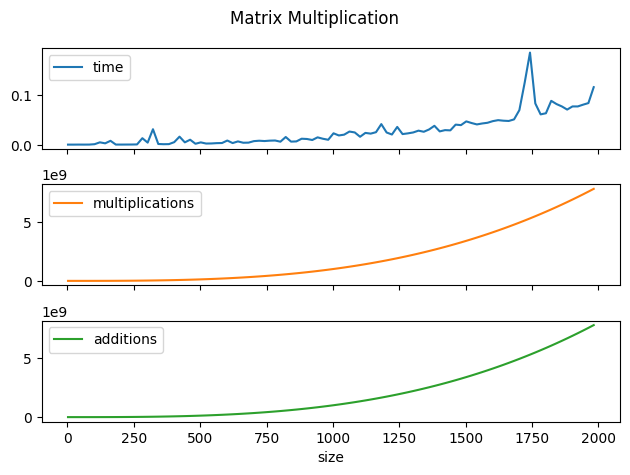

In [16]:
df_matmul.plot(x="size", y=["time", "multiplications", "additions"], subplots=True, title="Matrix Multiplication")
plt.tight_layout()

### Rekurencyjne odwracanie macierzy

In [17]:
def benchmark_inverse(A):
    inverse.multiplications = 0
    inverse.additions = 0
    matmul.multiplications = 0
    matmul.additions = 0

    start_time = perf_counter()
    result = inverse(A)
    end_time = perf_counter()
    numpy_diff = np.max(np.abs(result - np.linalg.inv(A)))

    return {
        "size": A.shape[0],
        "time": end_time - start_time,
        "multiplications": inverse.multiplications + matmul.multiplications,
        "additions": inverse.additions + matmul.additions,
        "numpy_diff": numpy_diff
    }

In [18]:
results = []
for X in X_bench:
    result = benchmark_inverse(X)
    results.append(result)

df_inverse = pd.DataFrame(results)

,size,time,multiplications,additions,numpy_diff
0,2,0.000134,14,2,6.439294e-15
10,202,0.021611,13761480,13558550,5.081990e-06
20,402,0.034460,108374872,107569084,1.059671e-05
30,602,0.059467,363829962,362021526,3.371776e-06
40,802,0.118118,860161656,856950154,3.349766e-06
50,1002,0.107630,1677292658,1672278542,7.980708e-05
60,1202,0.133315,2895325186,2888108572,1.284770e-06
70,1402,0.205637,4594174862,4584355060,5.055048e-05
80,1602,0.339264,6853975224,6841152296,1.510269e-06
90,1802,0.323631,9754416798,9738191500,5.103306e-01


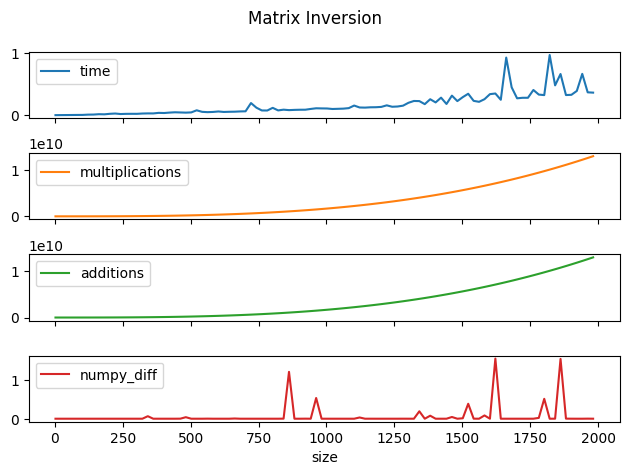

In [19]:
df_inverse.plot(x="size", y=["time", "multiplications", "additions", "numpy_diff"], subplots=True, title="Matrix Inversion")
plt.tight_layout()
display(df_inverse[::10])

### Rekurencyjna LU faktoryzacja

In [20]:
def benchmark_lu(A):
    lu.multiplications = 0
    lu.additions = 0
    inverse.multiplications = 0
    inverse.additions = 0
    matmul.multiplications = 0
    matmul.additions = 0

    start_time = perf_counter()
    result = lu(A)
    end_time = perf_counter()
    L, U = result
    numpy_diff = np.max(np.abs(A - L @ U))

    return {
        "size": A.shape[0],
        "time": end_time - start_time,
        "multiplications": lu.multiplications
        + inverse.multiplications
        + matmul.multiplications,
        "additions": lu.additions + inverse.additions + matmul.additions,
        "numpy_diff": numpy_diff
    }

In [21]:
results = []
for X in X_bench:
    result = benchmark_lu(X)
    results.append(result)

df_lu = pd.DataFrame(results)

,size,time,multiplications,additions,numpy_diff
0,2,0.000221,7,1,1.776357e-15
10,202,0.102450,11408881,11134021,2.937384e-11
20,402,0.270913,90104225,88996849,5.208253e-08
30,602,0.457296,302658171,300162225,3.455752e-08
40,802,0.522555,716053297,711602781,8.130150e-08
50,1002,0.752490,1396304375,1389345133,2.821565e-08
60,1202,1.103935,2410878731,2400855445,5.749526e-07
70,1402,1.628714,3825757079,3812099969,4.856943e-06
80,1602,1.395587,5708868209,5691015193,7.984924e-06
90,1802,1.706230,8124251411,8101652493,3.232527e-07


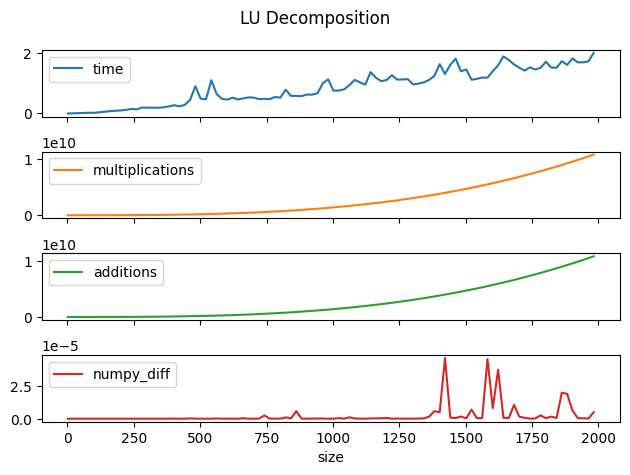

In [22]:
df_lu.plot(x="size", y=["time", "multiplications", "additions", "numpy_diff"], subplots=True, title="LU Decomposition")
plt.tight_layout()
display(df_lu[::10])

### Rekurencyjna eliminacja Gaussa

In [23]:
def benchmark_gaussian_elimination(A, b):
    gaussian_elimination.multiplications = 0
    gaussian_elimination.additions = 0
    lu.multiplications = 0
    lu.additions = 0
    inverse.multiplications = 0
    inverse.additions = 0
    matmul.multiplications = 0
    matmul.additions = 0

    start_time = perf_counter()
    result = gaussian_elimination(A, b)
    end_time = perf_counter()
    C, RHS = result
    x = np.linalg.solve(C, RHS)
    numpy_diff = np.max(np.abs(np.matmul(A, x) - b))

    return {
        "size": A.shape[0],
        "time": end_time - start_time,
        "multiplications": gaussian_elimination.multiplications
        + lu.multiplications
        + inverse.multiplications
        + matmul.multiplications,
        "additions": gaussian_elimination.additions
        + lu.additions
        + inverse.additions
        + matmul.additions,
        "numpy_diff": numpy_diff
    }

In [24]:
results = []
for X, b in zip(X_bench, b_bench):
    result = benchmark_gaussian_elimination(X, b)
    results.append(result)

df_gaussian_elimination = pd.DataFrame(results)

,size,time,multiplications,additions,numpy_diff
0,2,0.000155,12,2,3.885781e-15
10,202,0.072220,12148619,11843196,9.447221e-11
20,402,0.268482,95729659,94501191,1.091448e-07
30,602,0.407953,321310150,318542688,2.451492e-07
40,802,0.656992,759890123,754957458,1.923163e-07
50,1002,0.961732,1481445702,1473733904,3.235262e-07
60,1202,1.050933,2557495322,2546389131,1.616877e-06
70,1402,1.159726,4057977508,4042846799,2.122694e-05
80,1602,1.442090,6054887819,6035110541,3.806602e-05
90,1802,2.372943,8616110808,8591077343,9.188984e-06


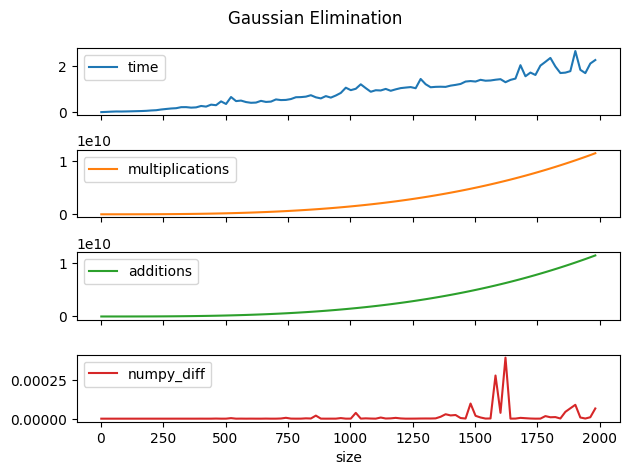

In [25]:
df_gaussian_elimination.plot(x="size", y=["time", "multiplications", "additions", "numpy_diff"], subplots=True, title="Gaussian Elimination")
plt.tight_layout()
display(df_gaussian_elimination[::10])

### Rekurencyjne liczenie wyznacznika

In [26]:
def benchmark_det(A):
    det.multiplications = 0
    det.additions = 0
    lu.multiplications = 0
    lu.additions = 0
    inverse.multiplications = 0
    inverse.additions = 0
    matmul.multiplications = 0
    matmul.additions = 0

    start_time = perf_counter()
    result = det(A)
    end_time = perf_counter()
    numpy_diff = np.max(np.abs(result - np.linalg.det(A)))

    return {
        "size": A.shape[0],
        "time": end_time - start_time,
        "multiplications": det.multiplications
        + lu.multiplications
        + inverse.multiplications
        + matmul.multiplications,
        "additions": det.additions
        + lu.additions
        + inverse.additions
        + matmul.additions,
        "numpy_diff": numpy_diff
    }

In [27]:
results = []
for X in X_bench:
    result = benchmark_det(X)
    results.append(result)

df_det = pd.DataFrame(results)

/mnt/c/Users/robert/Desktop/Algorytmy macierzowe/am-agh-2024/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/mnt/c/Users/robert/Desktop/Algorytmy macierzowe/am-agh-2024/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2432: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/tmp/ipykernel_42491/1035810227.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  numpy_diff = np.max(np.abs(result - np.linalg.det(A)))


,size,time,multiplications,additions,numpy_diff
0,2,0.000256,9,1,0.000000e+00
10,202,0.093259,11409083,11134021,4.819606e+70
20,402,0.246742,90104627,88996849,1.271657e+212
30,602,0.454300,302658773,300162225,NaN
40,802,0.515417,716054099,711602781,NaN
50,1002,0.712127,1396305377,1389345133,NaN
60,1202,0.925306,2410879933,2400855445,NaN
70,1402,1.237151,3825758481,3812099969,NaN
80,1602,1.225387,5708869811,5691015193,NaN
90,1802,1.491398,8124253213,8101652493,NaN


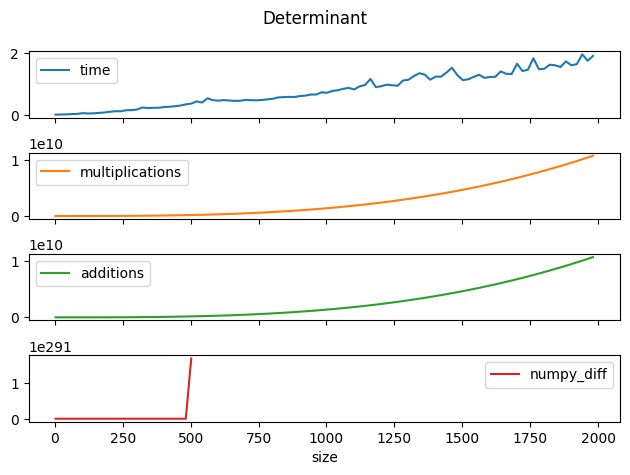

In [28]:
df_det.plot(x="size", y=["time", "multiplications", "additions", "numpy_diff"], subplots=True, title="Determinant")
plt.tight_layout()
display(df_det[::10])

## Oszacowana złożoność czasowa

In [29]:
def plot_best_cubic(size, time, name):
    plt.scatter(size, time, label="Actual Data")

    coeffs = np.polyfit(size, time, 3)

    x_smooth = np.linspace(min(size), max(size), 200)
    y_smooth = np.polyval(coeffs, x_smooth)

    plt.plot(x_smooth, y_smooth, color="red", label="Cubic Fit")

    plt.xlabel("Size")
    plt.ylabel("Time")
    plt.title(f"{name} - $N^3$ Fit")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

### Mnożenie macierzy

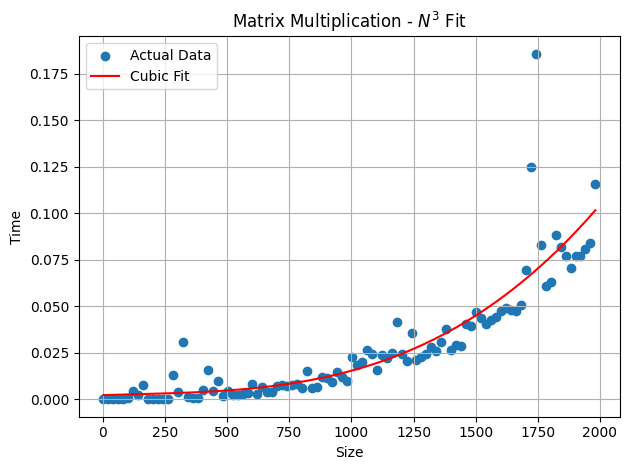

In [30]:
plot_best_cubic(df_matmul["size"], df_matmul["time"], "Matrix Multiplication")

### Rekurencyjne odwracanie macierzy

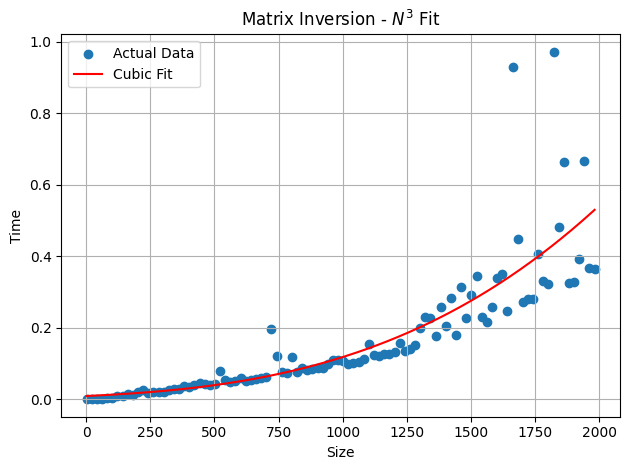

In [31]:
plot_best_cubic(df_inverse["size"], df_inverse["time"], "Matrix Inversion")

### Rekurencyjna LU faktoryzacja

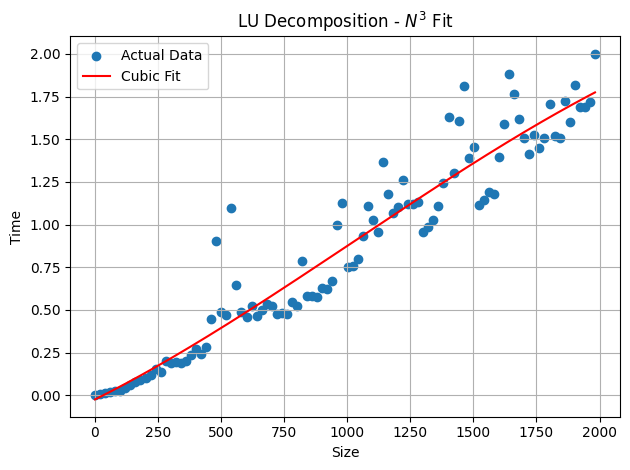

In [32]:
plot_best_cubic(df_lu["size"], df_lu["time"], "LU Decomposition")

### Rekurencyjna eliminacja Gaussa

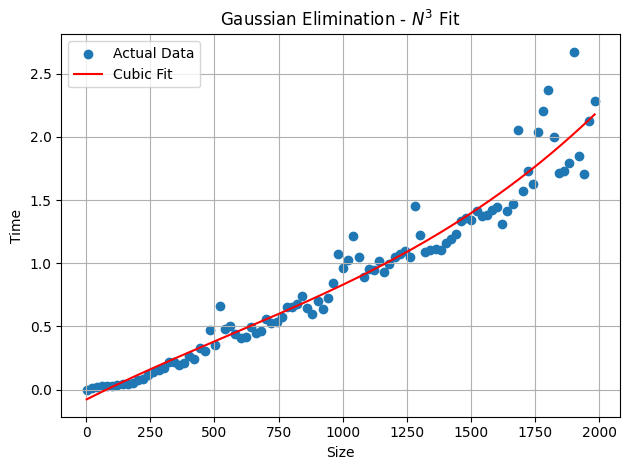

In [33]:
plot_best_cubic(df_gaussian_elimination["size"], df_gaussian_elimination["time"], "Gaussian Elimination")

### Rekurencyjne liczenie wyznacznika

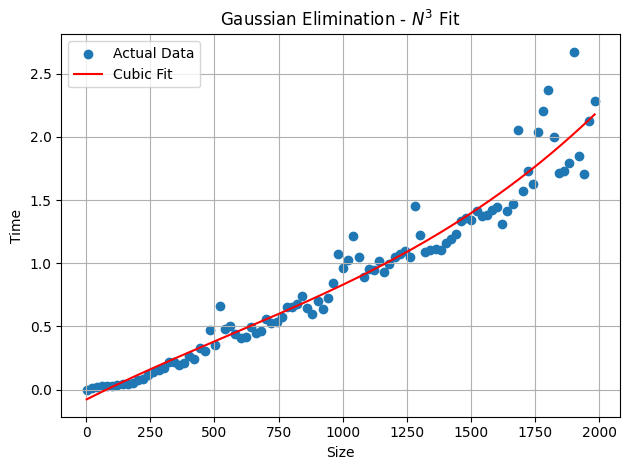

In [34]:
plot_best_cubic(df_gaussian_elimination["size"], df_gaussian_elimination["time"], "Gaussian Elimination")